In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from lsst.utils.plotting.figures import make_figure


In [3]:
from lsst.summit.utils.guiders.reading import GuiderReader
import lsst.summit.utils.butlerUtils as butlerUtils
from lsst.daf.butler import Butler

butler = Butler("main", collections=["LSSTCam/raw/guider", "LSSTCam/raw/all"])


dayObs = 20251120
seqNum = 53

# dayObs = 20251119     # YYYYMMDD
# seqNum = 119          # sequence number in that night

# dayObs = 20251121
# seqNum = 34

reader = GuiderReader(butler, view="dvcs")
guiderData = reader.get(dayObs=dayObs, seqNum=seqNum, doSubtractMedian=True)

In [4]:
from lsst.summit.utils.guiders.tracking import GuiderStarTracker, GuiderStarTrackerConfig
config = GuiderStarTrackerConfig()
starTracker = GuiderStarTracker(guiderData, config)
stars = starTracker.trackGuiderStars(refCatalog=None)

In [5]:
stars

,trackid,detector,expid,elapsed_time,dalt,daz,dtheta,dx,dy,fwhm,...,e1,e2,e1_altaz,e2_altaz,ampname,timestamp,stamp,detid,filter,exptime
0,189001,R00_SG0,2025112000053,0.596698,-0.351176,0.149319,4.167469,0.473378,-1.894189,1.771159,...,-0.095451,-0.069583,-0.083617,-0.083431,C14,2461000.5585582573,1,189,g,14.91732
1,189002,R00_SG0,2025112000053,1.193355,-0.165039,0.079474,0.659547,0.243956,-0.924020,1.826282,...,-0.004880,-0.049569,0.002799,-0.049730,C14,2461000.558565163,2,189,g,14.91732
2,189003,R00_SG0,2025112000053,1.790053,0.007693,0.064648,-3.436131,0.279657,-0.056008,1.728787,...,-0.124734,-0.025750,-0.119292,-0.044622,C14,2461000.5585720693,3,189,g,14.91732
3,189004,R00_SG0,2025112000053,2.386670,-0.007693,0.007287,-2.084648,-0.015354,-0.095417,1.839824,...,0.015333,0.081963,0.002549,0.083345,C14,2461000.5585789746,4,189,g,14.91732
4,189005,R00_SG0,2025112000053,2.983367,0.035902,-0.560376,6.362707,-2.810780,0.487943,2.138538,...,0.023689,-0.159601,0.047946,-0.154061,C14,2461000.558585881,5,189,g,14.91732
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,202020,R44_SG1,2025112000053,11.933792,-0.322935,0.138177,-1.476171,1.687848,0.601174,1.734005,...,0.064427,-0.005042,0.064436,0.004924,C06,2461000.5586894737,20,202,g,14.91732
140,202021,R44_SG1,2025112000053,12.530570,-0.170894,0.066501,-0.140113,0.909801,0.275458,1.481686,...,0.034194,0.113766,0.016295,0.117671,C06,2461000.558696381,21,202,g,14.91732
141,202022,R44_SG1,2025112000053,13.127227,-0.050347,0.113585,3.310186,0.316860,0.537415,1.437712,...,0.091449,0.008174,0.089105,0.022137,C06,2461000.5587032866,22,202,g,14.91732
142,202023,R44_SG1,2025112000053,13.723925,0.067536,0.259578,8.983998,-0.239958,1.293943,1.404904,...,0.071612,0.021272,0.067490,0.032030,C06,2461000.558710193,23,202,g,14.91732


In [6]:
from lsst.summit.utils.guiders.metrics import GuiderMetricsBuilder

expid = dayObs*100000 + seqNum

metricsBuilder = GuiderMetricsBuilder(stars, nMissingStamps=0)
metricsDf = metricsBuilder.buildMetrics(expid)
metricsDf

,n_guiders,n_stars,n_missing_stamps,n_measurements,fraction_possible_measurements,exptime,R00_SG0,R00_SG1,R04_SG0,R04_SG1,...,mag_outlier_frac,mag_slope_significance,mag_nsize,psf_slope,psf_intercept,psf_trend_rmse,psf_global_std,psf_outlier_frac,psf_slope_significance,psf_nsize
2025112000053,6,6,0,144,1.0,14.91732,True,True,True,True,...,0.194444,1.75302,144,-0.003499,1.717794,0.118155,0.154578,0.125,1.354358,144


In [16]:
from lsst.summit.utils.guiders.plotting import GuiderPlotter

plotter = GuiderPlotter(guiderData, stars)

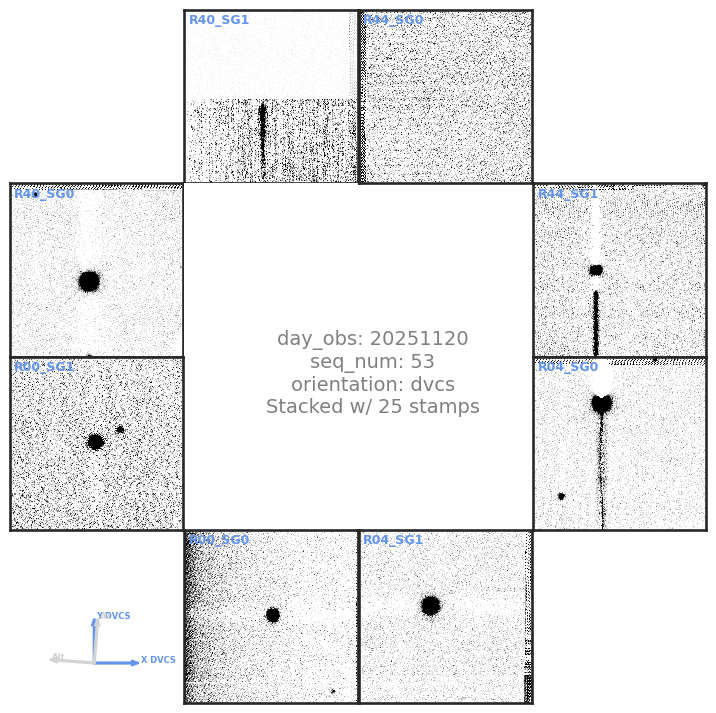

In [8]:
plotter.plotMosaic(stampNum=-1, cutoutSize=-1, plo=50, phi=98, saveAs=f'guider_{expid}')


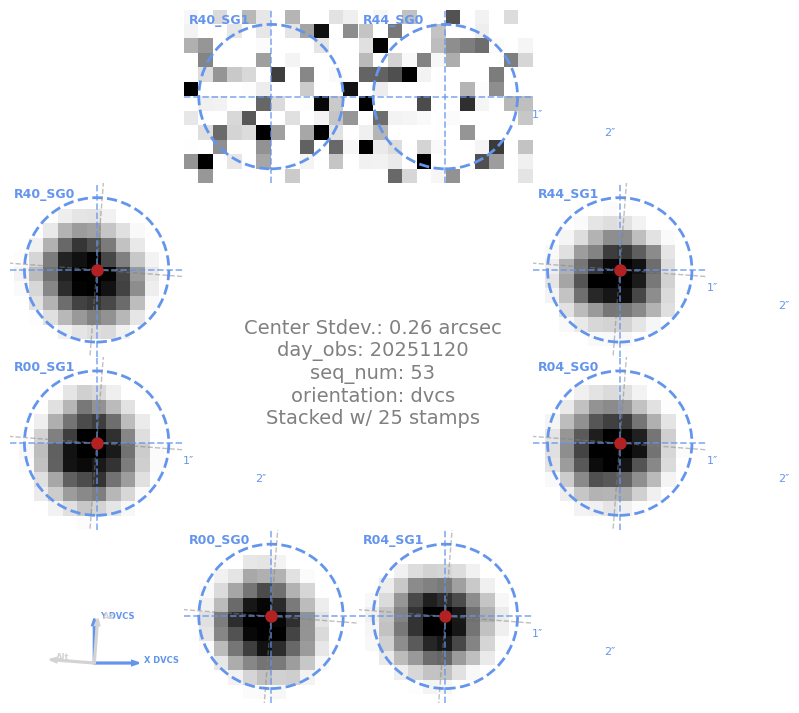

In [9]:
fname = f'./star_mosaic_full_{dayObs}_{seqNum}.png'
plotter.plotMosaic(stampNum=-1, cutoutSize=12, plo=50, phi=98, saveAs=fname)

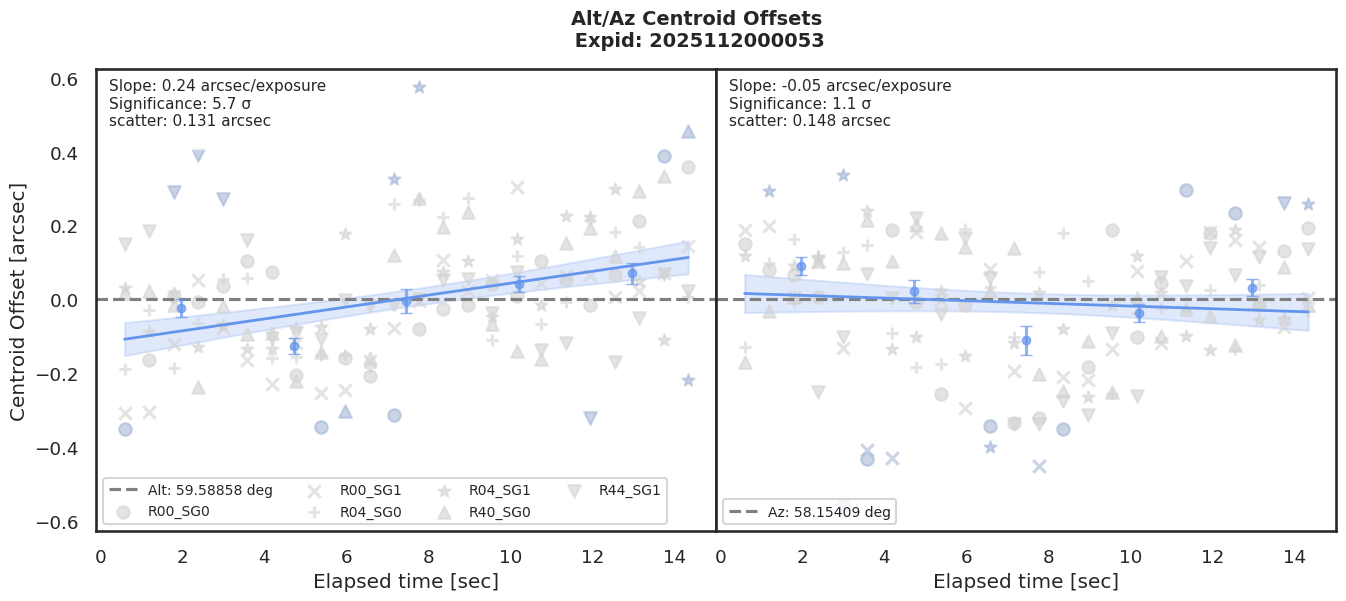

In [10]:
fname = f'./strip_plot_altaz_{dayObs}_{seqNum}.png'
plotter.stripPlot(saveAs=fname)

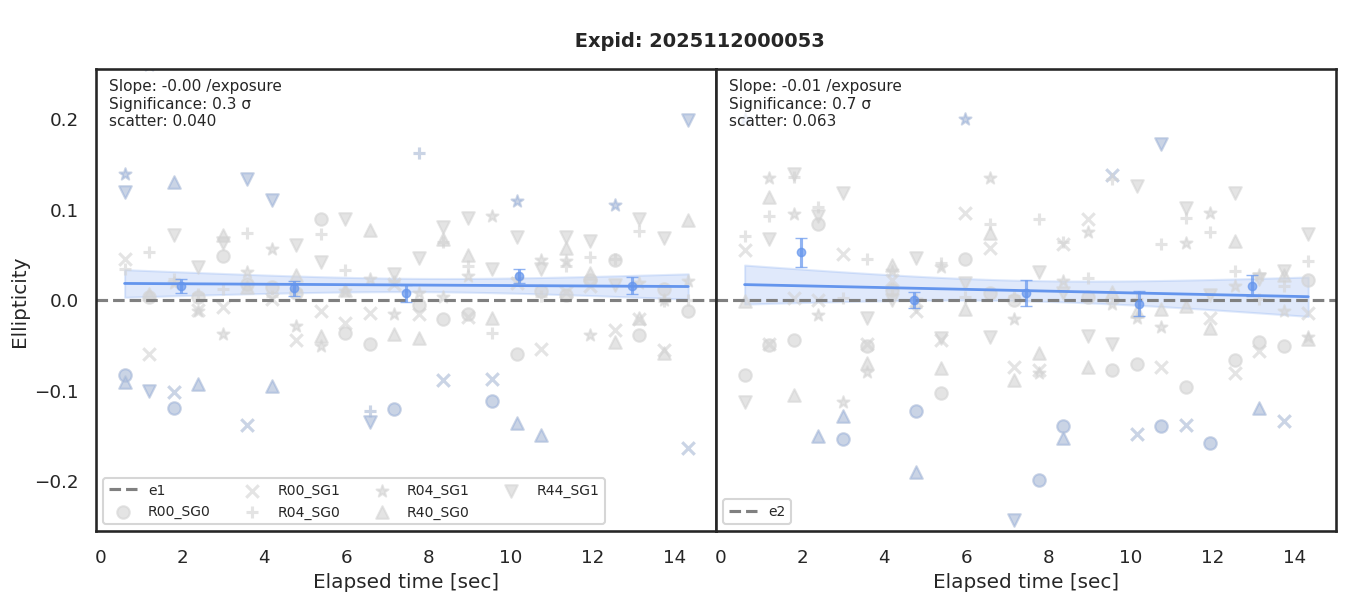

In [11]:
fname = f'./strip_plot_ellip_{dayObs}_{seqNum}.png'
plotter.stripPlot(plotType='ellip', saveAs=fname)


In [12]:
fname = f'./star_mosaic_full_{dayObs}_{seqNum}.gif'
plotter.makeAnimation(cutoutSize=20, plo=50, phi=98, saveAs=fname)

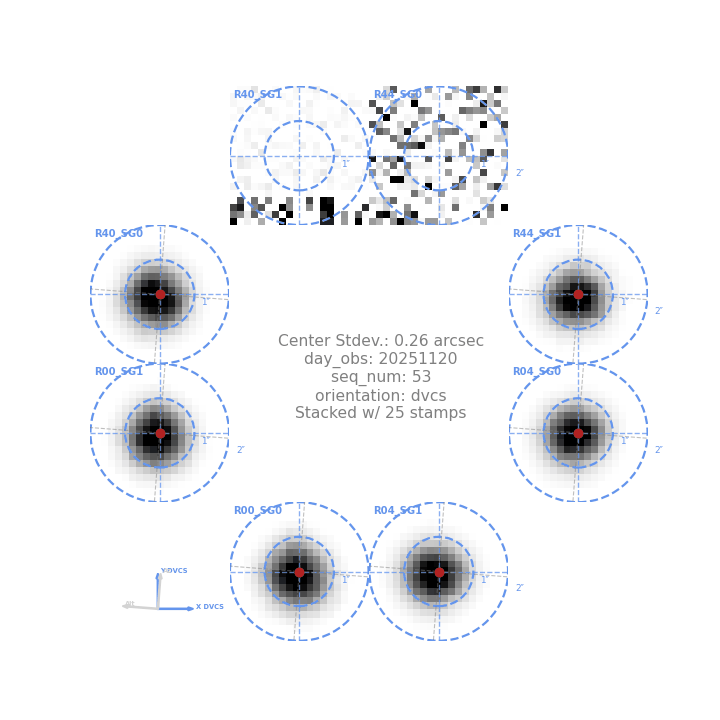

In [13]:
from IPython.display import Image, display
display(Image(filename=fname))

In [20]:
image = guiderData.getStampArrayCoadd("R44_SG1")
